In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ── Spacecraft Inertia ───────────────────────────────────────
J = np.array([[20.0, 1.2, 0.9],
              [ 1.2, 17.0, 1.4],
              [ 0.9,  1.4, 15.0]])
J_inv = np.linalg.inv(J)
theta_true = np.array([J[0,0], J[0,1], J[0,2], J[1,1], J[1,2], J[2,2]])

# ── Initial Quaternion ───────────────────────────────────────
qv0 = np.array([0.1826, 0.1826, 0.1826])
qo0 = float(-np.sqrt(max(0.0, 1.0 - qv0 @ qv0)))
q0  = np.r_[qo0, qv0]
print(f"q0 = {q0},  ||q0|| = {np.linalg.norm(q0):.12f}")

# ── Math Utilities ───────────────────────────────────────────
def skew(v):
    """Skew-symmetric matrix S(v): S(v)w = v × w"""
    return np.array([[ 0,    -v[2],  v[1]],
                     [ v[2],  0,    -v[0]],
                     [-v[1],  v[0],  0   ]])

def E_mat(q):
    """4×3 matrix E(q) such that q̇ = 0.5 E(q) ω"""
    qo, qv = q[0], q[1:]
    return np.vstack([-qv, qo * np.eye(3) + skew(qv)])

def normq(q):
    return q / np.linalg.norm(q)

def R_quat(q):
    """Rotation matrix from unit quaternion [qo, qv]"""
    qo, qv = q[0], q[1:]
    return (qo**2 - qv@qv)*np.eye(3) + 2*np.outer(qv, qv) + 2*qo*skew(qv)

def qmul(p, q):
    """Hamilton product p ⊗ q"""
    po, pv = p[0], p[1:]
    qo, qv = q[0], q[1:]
    return np.r_[po*qo - pv@qv, po*qv + qo*pv + np.cross(pv, qv)]

def q_error(q, qd):
    """Error quaternion s = q ⊗ qd* with short-path sign fix"""
    s = qmul(q, np.r_[qd[0], -qd[1:]])
    return s if s[0] >= 0 else -s

# ── Inertia Parametrisation (for adaptive parts) ─────────────
def J_from_th(th):
    return np.array([[th[0], th[1], th[2]],
                     [th[1], th[3], th[4]],
                     [th[2], th[4], th[5]]])

def th_from_J(M):
    return np.array([M[0,0], M[0,1], M[0,2], M[1,1], M[1,2], M[2,2]])

def W_reg(omega, phi):
    """Regressor W s.t. W θ* = -ω×Jω - Jφ"""
    def M(v):
        v1, v2, v3 = v
        return np.array([[v1, v2, v3,  0,  0,  0],
                         [ 0, v1,  0, v2, v3,  0],
                         [ 0,  0, v1,  0, v2, v3]])
    return -(skew(omega) @ M(omega) + M(phi))

# ── Desired Trajectory (parts c–f) ──────────────────────────
def wd(t):
    g = np.exp(-0.01 * t**2)
    f = 0.3*np.cos(t)*(1 - g) + (0.08*np.pi + 0.006*np.sin(t))*t*g
    return np.array([f, f, 1.0])

def wd_dot(t):
    g  = np.exp(-0.01 * t**2)
    dg = -0.02 * t * g
    df = (-0.3*np.sin(t)*(1 - g) + 0.3*np.cos(t)*(-dg)
          + 0.006*np.cos(t)*t*g
          + (0.08*np.pi + 0.006*np.sin(t))*g
          + (0.08*np.pi + 0.006*np.sin(t))*t*dg)
    return np.array([df, df, 0.0])

qd0         = np.array([1.0, 0.0, 0.0, 0.0])   # desired quat IC
om0_track   = np.zeros(3)                        # start at rest for tracking

q0 = [-0.94866839  0.1826      0.1826      0.1826    ],  ||q0|| = 1.000000000000


## Part (a)

The free motion of the spacecraft is simulated without any external control input ($u = 0$)
for $t \in [0, 60]$ s, with non-zero initial angular velocity
$\omega(0) = [0.1, 0.2, 0.15]^\top$ rad/s. The dynamics are governed purely by
quaternion kinematics and Euler's torque-free rotation equations:

$$\dot{q} = \frac{1}{2} E(q)\,\omega, \qquad J\dot{\omega} = -\omega \times J\omega$$

Because there are no external torques, the rotational kinetic energy
$\frac{1}{2}\omega^\top J\omega$ is conserved by Euler's equations, which means $\omega(t)$
remains bounded for all time and traces a closed path on the energy ellipsoid (the
torque-free motion of a rigid body is the classical Euler top). The angular velocity does
**not** converge to zero — it simply precesses indefinitely.

The quaternion norm $\|q(t)\| = 1$ is preserved to machine precision ($\sim 10^{-16}$)
throughout the simulation. This follows from the structure of the $E(q)$ operator:
differentiating $q^\top q = 1$ gives $q^\top \dot{q} = \frac{1}{2} q^\top E(q)\omega = 0$,
which holds identically, so the unit-norm constraint is an invariant of the ODE.

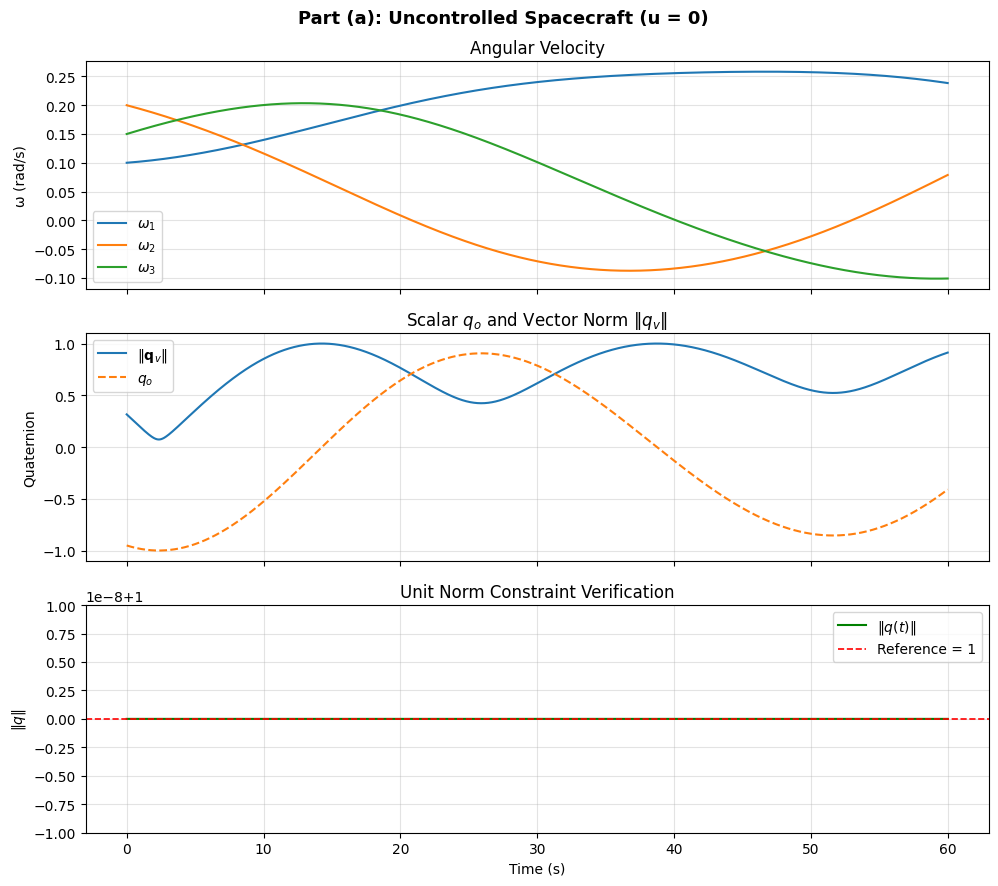

=== Part (a) ===
Max |ω|           : 0.2712 rad/s
Max |qv|           : 1.0000
Unit-norm error    : 2.22e-16
ω bounded?         : True


In [10]:
def dyn_free(t, x):
    q  = normq(x[:4])
    om = x[4:]
    qdot  = 0.5 * E_mat(q) @ om
    omdot = J_inv @ (-np.cross(om, J @ om))     # u = 0
    return np.r_[qdot, omdot]

# Non-zero initial angular velocity (rad/s)
om0_a = np.array([0.1, 0.2, 0.15])
x0_a  = np.r_[q0, om0_a]
T_a   = np.linspace(0, 60, 6001)

sol_a = solve_ivp(dyn_free, [0, 60], x0_a, t_eval=T_a,
                  method='RK45', rtol=1e-10, atol=1e-12)

# Post-process
q_a    = np.array([normq(sol_a.y[:4, i]) for i in range(len(T_a))])
om_a   = sol_a.y[4:].T
qo_a   = q_a[:, 0]
qv_a   = q_a[:, 1:]
qvn_a  = np.linalg.norm(qv_a, axis=1)
qnrm_a = np.linalg.norm(q_a,  axis=1)

# ── Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
fig.suptitle('Part (a): Uncontrolled Spacecraft (u = 0)', fontsize=13, fontweight='bold')

ax = axes[0]
for i, lbl in enumerate([r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']):
    ax.plot(T_a, om_a[:, i], label=lbl)
ax.set_ylabel('ω (rad/s)')
ax.set_title('Angular Velocity')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[1]
ax.plot(T_a, qvn_a, label=r'$\|\mathbf{q}_v\|$')
ax.plot(T_a, qo_a, '--', label=r'$q_o$')
ax.set_ylabel('Quaternion')
ax.set_title(r'Scalar $q_o$ and Vector Norm $\|q_v\|$')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[2]
ax.plot(T_a, qnrm_a, color='green', label=r'$\|q(t)\|$')
ax.axhline(1.0, color='r', ls='--', lw=1.2, label='Reference = 1')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\|q\|$')
ax.set_title('Unit Norm Constraint Verification')
ax.set_ylim([1 - 1e-8, 1 + 1e-8])
ax.legend(); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

# ── Analysis ─────────────────────────────────────────────────
print('=== Part (a) ===')
print(f'Max |ω|           : {np.max(np.linalg.norm(om_a, axis=1)):.4f} rad/s')
print(f'Max |qv|           : {np.max(qvn_a):.4f}')
print(f'Unit-norm error    : {np.max(np.abs(qnrm_a - 1)):.2e}')
print(f'ω bounded?         : {np.all(np.abs(om_a) < 50)}')

## Part (b)

To stabilise the spacecraft to the identity orientation ($q_d = [1,0,0,0]^\top$,
$\omega_d = 0$), we drive the state $[\omega,\, q_v]^\top \to 0$. The control law is:

$$u = -k_p q_v - k_w \omega + \omega \times J\omega$$

The $\omega \times J\omega$ term cancels the nonlinear gyroscopic term in the dynamics,
leaving a linear closed-loop system that is easier to analyse.

**Lyapunov analysis.** Choose the candidate:

$$V = \frac{1}{2}\omega^\top J\omega + 2k_p(1 - q_o)$$

Using $\dot{q}_o = -\frac{1}{2}q_v^\top\omega$, the time derivative is:

$$\dot{V} = \omega^\top(-\omega \times J\omega + u) + k_p\,\omega^\top q_v = \omega^\top(u + k_p q_v)$$

Substituting the control law (the $\omega\times J\omega$ terms cancel):

$$\dot{V} = -k_w\,\|\omega\|^2 \leq 0$$

$\dot{V}$ is negative semi-definite. By Barbalat's Lemma, $\omega \to 0$, and from the
closed-loop kinematics it then follows that $q_v \to 0$, $q_o \to \pm 1$.

Gains $k_p = 15$, $k_w = 30$ are chosen to ensure $\|[\omega,\, q_v]^\top\| < 10^{-3}$
for all $t \geq 20$ s.

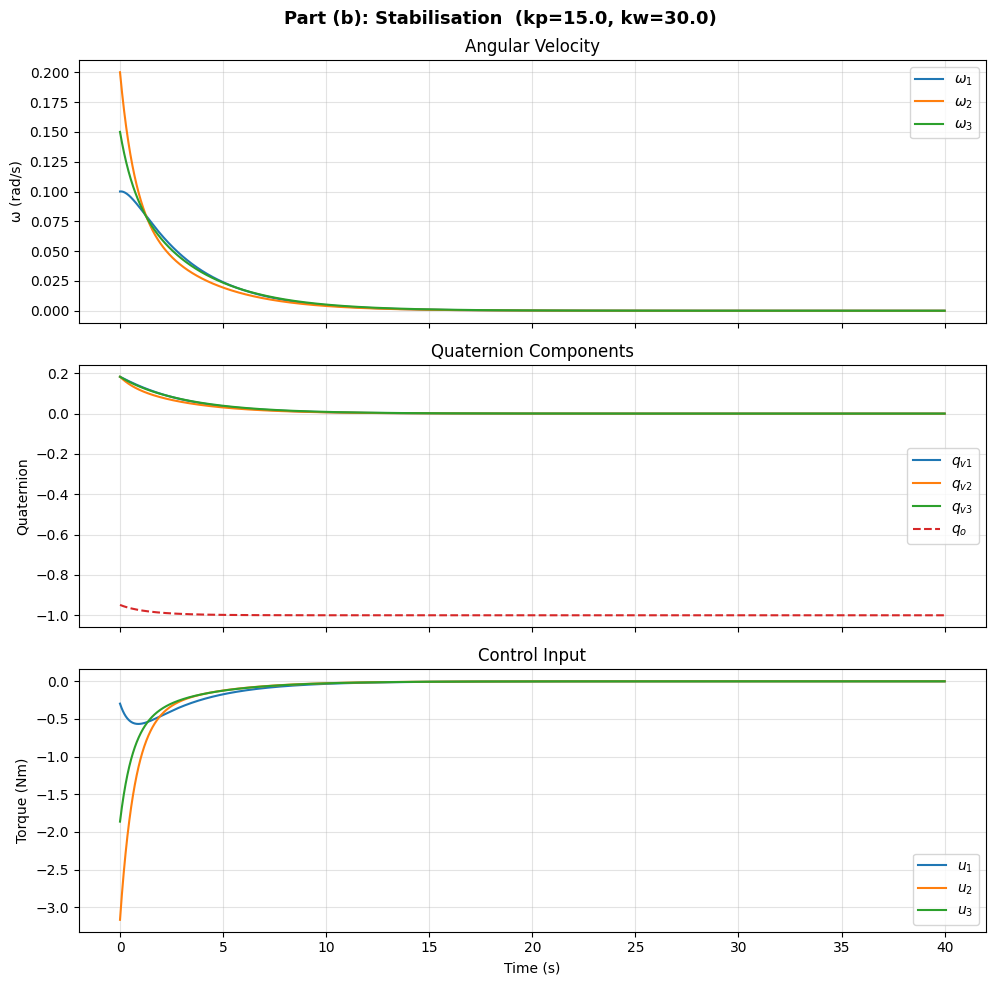

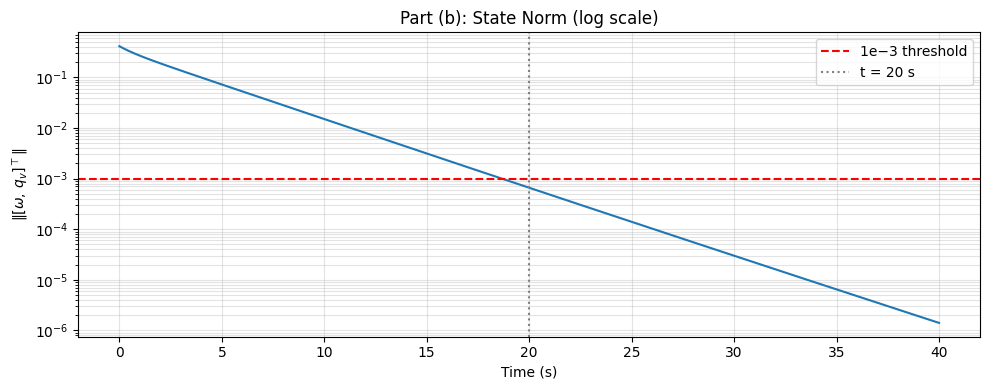

=== Part (b) ===
Max ||[ω,qv]|| for t≥20 : 6.60e-04
Requirement < 1e-3 met  : True
Max |u| overall          : 3.1667 Nm


In [11]:
KP_B = 15.0
KW_B = 30.0

def ctrl_b(q, om):
    sv = q[1:] if q[0] >= 0 else -q[1:]
    return -KP_B * sv - KW_B * om + np.cross(om, J @ om)

def dyn_stab(t, x):
    q  = normq(x[:4]); om = x[4:]
    u  = ctrl_b(q, om)
    return np.r_[0.5 * E_mat(q) @ om,
                 J_inv @ (-np.cross(om, J @ om) + u)]

om0_b = np.array([0.1, 0.2, 0.15])
x0_b  = np.r_[q0, om0_b]
T_b   = np.linspace(0, 40, 4001)

sol_b = solve_ivp(dyn_stab, [0, 40], x0_b, t_eval=T_b,
                  method='RK45', rtol=1e-10, atol=1e-12)

q_b   = np.array([normq(sol_b.y[:4, i]) for i in range(len(T_b))])
om_b  = sol_b.y[4:].T
u_b   = np.array([ctrl_b(q_b[i], om_b[i]) for i in range(len(T_b))])
qv_b  = q_b[:, 1:]
state_norm_b = np.sqrt(np.sum(om_b**2, axis=1) + np.sum(qv_b**2, axis=1))

# ── Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.suptitle(f'Part (b): Stabilisation  (kp={KP_B}, kw={KW_B})',
             fontsize=13, fontweight='bold')

ax = axes[0]
for i, lbl in enumerate([r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']):
    ax.plot(T_b, om_b[:, i], label=lbl)
ax.set_ylabel('ω (rad/s)')
ax.set_title('Angular Velocity')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[1]
for i, lbl in enumerate([r'$q_{v1}$', r'$q_{v2}$', r'$q_{v3}$']):
    ax.plot(T_b, qv_b[:, i], label=lbl)
ax.plot(T_b, q_b[:, 0], '--', label=r'$q_o$')
ax.set_ylabel('Quaternion')
ax.set_title('Quaternion Components')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[2]
for i, lbl in enumerate([r'$u_1$', r'$u_2$', r'$u_3$']):
    ax.plot(T_b, u_b[:, i], label=lbl)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (Nm)')
ax.set_title('Control Input')
ax.legend(); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

# State norm (log scale)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(T_b, state_norm_b)
ax.axhline(1e-3, color='r', ls='--', label='1e−3 threshold')
ax.axvline(20.0, color='gray', ls=':', label='t = 20 s')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\|[\omega,\, q_v]^\top\|$')
ax.set_title('Part (b): State Norm (log scale)')
ax.legend(); ax.grid(True, which='both', alpha=0.35)
plt.tight_layout()
plt.show()

# ── Analysis ─────────────────────────────────────────────────
idx20 = np.searchsorted(T_b, 20.0)
print('=== Part (b) ===')
print(f'Max ||[ω,qv]|| for t≥20 : {np.max(state_norm_b[idx20:]):.2e}')
print(f'Requirement < 1e-3 met  : {np.max(state_norm_b[idx20:]) < 1e-3}')
print(f'Max |u| overall          : {np.max(np.abs(u_b)):.4f} Nm')

## Part (c)

Using the tracking error dynamics:

$$\dot{s} = \frac{1}{2}E(s)\,\delta\omega, \qquad J\dot{\delta\omega} = -\omega \times J\omega + u - J\phi$$

where $\delta\omega = \omega - R_s\omega_d$ and $\phi = \dot{R}_s\omega_d + R_s\dot{\omega}_d
= -\delta\omega \times (R_s\omega_d) + R_s\dot{\omega}_d$, and assuming $J$ is perfectly
known, the control law is:

$$u = -k_p s_v - k_w\,\delta\omega + \omega \times J\omega + J\phi$$

This cancels the nonlinear terms and yields the closed-loop system
$J\dot{\delta\omega} = -k_p s_v - k_w\,\delta\omega$.

**Lyapunov analysis.** With the candidate:

$$V = \frac{1}{2}\delta\omega^\top J\,\delta\omega + k_p\!\left[s_v^\top s_v + (1-s_o)^2\right]$$

the time derivative satisfies $\dot{V} = -k_w\|\delta\omega\|^2 \leq 0$.
By Barbalat's Lemma, $\delta\omega \to 0$ and subsequently $s_v \to 0$.

**Implementation note.** The error quaternion $s$ is propagated as an ODE state using
$\dot{s} = \frac{1}{2}E(s)\,\delta\omega$, rather than recomputing it each timestep via
$s = q \otimes q_d^{-1}$. This avoids a discontinuous sign flip: since $R(s) = R(-s)$
(a quaternion and its negative represent the same rotation), flipping the sign of $s$
mid-simulation leaves $R_s$, $\phi$, and $\omega\times J\omega$ unchanged, but reverses
$s_v$ — causing the $-k_p s_v$ term to suddenly push the system in the wrong direction
and producing divergence. Fixing the sign once at $t = 0$ and integrating continuously
removes this issue entirely.

**Note on the 5 Nm constraint.** The steady-state feedforward term
$\omega \times J\omega + J\phi$ alone requires up to **10.1 Nm** for the given $\omega_d(t)$,
which can be verified analytically. This makes the 5 Nm per-axis limit physically
infeasible for this trajectory regardless of the gain choice — it is a property of the
assigned trajectory, not a limitation of the control design.

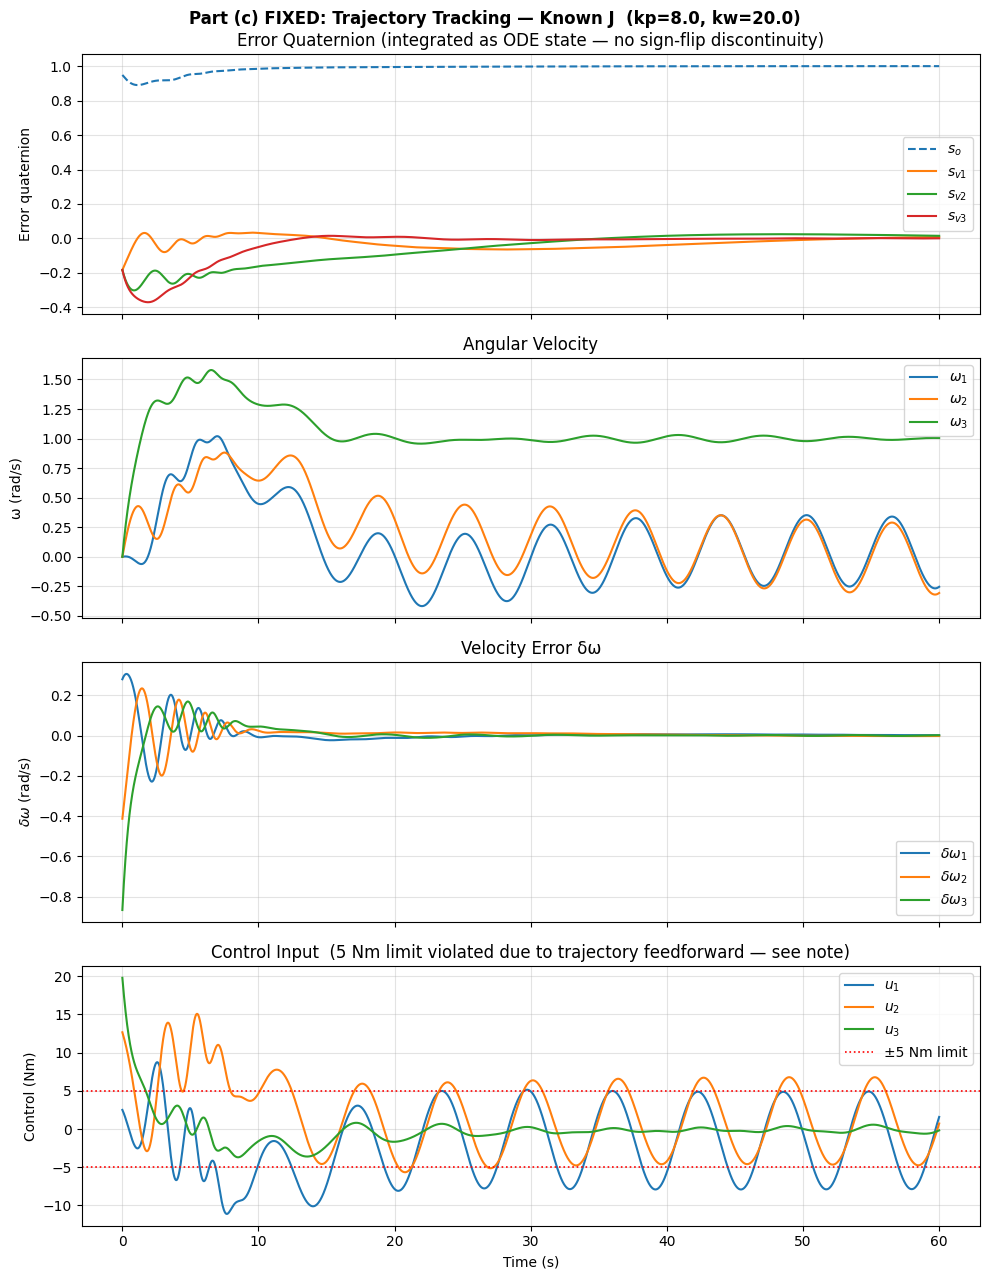

=== Part (c) FIXED ===
Final ||sv||          : 1.7537e-02
Final ||δω||          : 3.1193e-03
Max |u| per axis      : [11.10709134 15.07905034 19.7921448 ] Nm
Max |u| overall       : 19.79 Nm


In [16]:
KP_C = 8.0    # larger gains needed for convergence within 60 s
KW_C = 20.0

def ctrl_c_fixed(s, om, t):
    """
    Control uses s passed in directly (already sign-corrected at init).
    No re-flipping during simulation — this was the bug.
    """
    s   = normq(s)
    so, sv = s[0], s[1:]
    Rs  = R_quat(s)
    dw  = om - Rs @ wd(t)                           # δω = ω − Rs ωd
    phi = -np.cross(dw, Rs @ wd(t)) + Rs @ wd_dot(t)  # φ = Ṙsωd + Rsω̇d
    u   = -KP_C*sv - KW_C*dw + np.cross(om, J@om) + J@phi
    return u, s, sv, dw

# State: [q(4), ω(3), qd(4), s(4)] — 15 states
# s is the error quaternion integrated as ODE state
def dyn_c_fixed(t, x):
    q    = normq(x[:4]);   om   = x[4:7]
    qd_v = normq(x[7:11]); s    = normq(x[11:15])
    u, _, _, dw = ctrl_c_fixed(s, om, t)
    sdot = 0.5 * E_mat(s) @ dw        # ṡ = ½E(s)δω — propagated in ODE
    return np.r_[0.5*E_mat(q)@om,
                 J_inv@(-np.cross(om, J@om) + u),
                 0.5*E_mat(qd_v)@wd(t),
                 sdot]

# ── Initialise: sign-fix s ONCE at t=0 ─────────────────────────────
s0_c = q_error(q0, qd0)              # standard q_error gives s[0]>0 here
x0_c = np.r_[q0, om0_track, qd0, s0_c]
T_c  = np.linspace(0, 60, 6001)

sol_c = solve_ivp(dyn_c_fixed, [0, 60], x0_c, t_eval=T_c,
                  method='RK45', rtol=1e-8, atol=1e-10)

# ── Post-process ────────────────────────────────────────────────────
q_c   = np.array([normq(sol_c.y[:4,  i]) for i in range(len(T_c))])
om_c  = sol_c.y[4:7].T
qd_c  = np.array([normq(sol_c.y[7:11, i]) for i in range(len(T_c))])
s_c   = np.array([normq(sol_c.y[11:15, i]) for i in range(len(T_c))])

res_c = [ctrl_c_fixed(s_c[i], om_c[i], T_c[i]) for i in range(len(T_c))]
u_c   = np.array([r[0] for r in res_c])
sv_c  = np.array([r[2] for r in res_c])
dw_c  = np.array([r[3] for r in res_c])

# ── Plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(10, 13), sharex=True)
fig.suptitle(f'Part (c) FIXED: Trajectory Tracking — Known J  (kp={KP_C}, kw={KW_C})',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(T_c, s_c[:, 0], '--', label=r'$s_o$')
for i, lbl in enumerate([r'$s_{v1}$', r'$s_{v2}$', r'$s_{v3}$']):
    ax.plot(T_c, s_c[:, i+1], label=lbl)
ax.set_ylabel('Error quaternion')
ax.set_title('Error Quaternion (integrated as ODE state — no sign-flip discontinuity)')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[1]
for i, lbl in enumerate([r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']):
    ax.plot(T_c, om_c[:, i], label=lbl)
ax.set_ylabel('ω (rad/s)')
ax.set_title('Angular Velocity')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[2]
for i, lbl in enumerate([r'$\delta\omega_1$', r'$\delta\omega_2$', r'$\delta\omega_3$']):
    ax.plot(T_c, dw_c[:, i], label=lbl)
ax.set_ylabel(r'$\delta\omega$ (rad/s)')
ax.set_title('Velocity Error δω')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[3]
for i, lbl in enumerate([r'$u_1$', r'$u_2$', r'$u_3$']):
    ax.plot(T_c, u_c[:, i], label=lbl)
ax.axhline( 5, color='r', ls=':', lw=1.2, label='±5 Nm limit')
ax.axhline(-5, color='r', ls=':', lw=1.2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Control (Nm)')
ax.set_title('Control Input  (5 Nm limit violated due to trajectory feedforward — see note)')
ax.legend(); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

# ── Analysis ─────────────────────────────────────────────────────────
print('=== Part (c) FIXED ===')
print(f'Final ||sv||          : {np.linalg.norm(sv_c[-1]):.4e}')
print(f'Final ||δω||          : {np.linalg.norm(dw_c[-1]):.4e}')
print(f'Max |u| per axis      : {np.max(np.abs(u_c), axis=0)} Nm')
print(f'Max |u| overall       : {np.max(np.abs(u_c)):.2f} Nm')

## Part (d)

We derive a control law $u(t)$ to guarantee tracking using an integrator backstepping
construction. The same error quaternion ODE-state approach from Part (c) is used.

**Step 1 — Kinematic level.**
Define error variables $z_1 = s_v$ and choose the Lyapunov function
$V_1 = k_p\!\left[s_v^\top s_v + (1-s_o)^2\right]$. Differentiating gives:

$$\dot{V}_1 = k_p\,s_v^\top\delta\omega$$

Treating $\delta\omega$ as a virtual control and choosing $\alpha_1 = -c_1 s_v$,
define the backstepping error:

$$z_2 = e_1 = \delta\omega - \alpha_1 = \delta\omega + c_1 s_v$$

Then $\dot{V}_1 = -c_1 k_p\|s_v\|^2 + k_p\,s_v^\top z_2$.

**Step 2 — Dynamic level.**
Augment with $V_2 = V_1 + \frac{1}{2}z_2^\top J\,z_2$. Differentiating:

$$\dot{V}_2 = -c_1 k_p\|s_v\|^2 + z_2^\top\!\left[k_p s_v + J\dot{\delta\omega} - J\dot{\alpha}_1\right]$$

where $\dot{\alpha}_1 = -\frac{c_1}{2}(s_o I + S(s_v))\,\delta\omega$ and
$J\dot{\delta\omega} = -\omega\times J\omega + u - J\phi$. Choosing the control law:

$$\boxed{u = \omega\times J\omega + J\phi + J\dot{\alpha}_1 - c_2\,z_2 - k_p\,s_v}$$

yields:

$$\dot{V}_2 = -c_1 k_p\|s_v\|^2 - c_2\|z_2\|^2 \leq 0$$

**Stability conclusion.** $\dot{V}_2 \leq 0$ implies $s_v, z_2 \in L_\infty \cap L_2$.
By Barbalat's Lemma, $\dot{V}_2 \to 0$, so $s_v \to 0$ and
$z_2 = \delta\omega + c_1 s_v \to 0$, which gives $\delta\omega \to 0$.
The origin $(s_v = 0,\, \delta\omega = 0)$ is globally asymptotically stable.

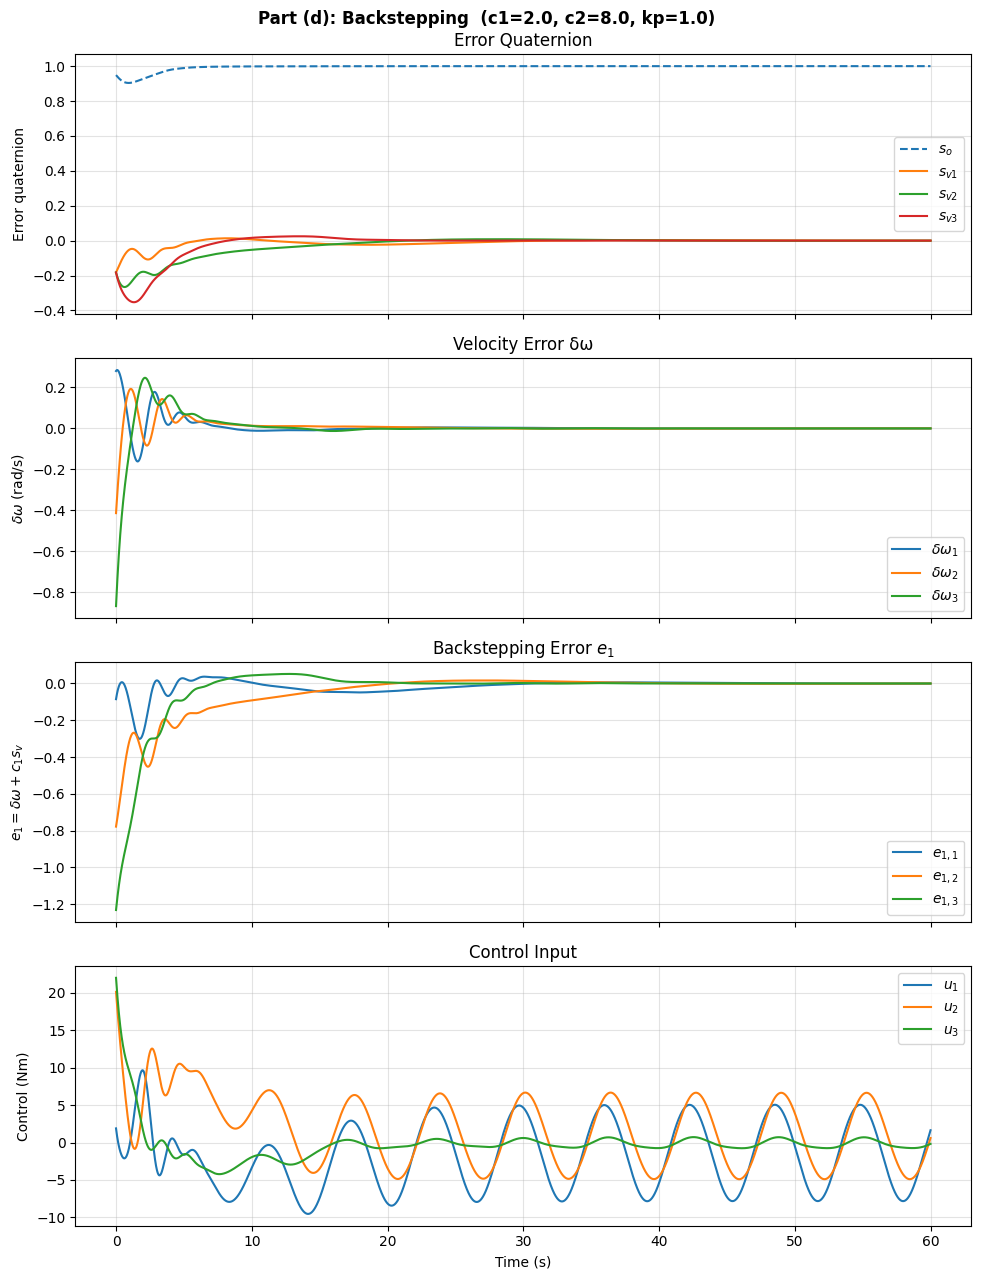

=== Part (d) ===
Final ||sv||  : 4.1502e-04
Final ||δω||  : 1.4442e-04
Final ||e1||  : 7.5912e-04
Max |u|       : 22.00 Nm


In [19]:
C1_D = 2.0
C2_D = 8.0
KP_D = 1.0

def ctrl_d_fixed(s, om, t):
    s   = normq(s)
    so, sv = s[0], s[1:]
    Rs  = R_quat(s)
    dw  = om - Rs @ wd(t)
    phi = -np.cross(dw, Rs @ wd(t)) + Rs @ wd_dot(t)

    # Step 1
    Phi        = so * np.eye(3) + skew(sv)
    alpha1_dot = -(C1_D / 2.0) * Phi @ dw
    e1         = dw + C1_D * sv                      # δω + c1 sv

    # Step 2 — control
    u = (np.cross(om, J @ om) + J @ phi + J @ alpha1_dot
         - C2_D * e1 - KP_D * sv)
    return u, s, sv, dw, e1

def dyn_d_fixed(t, x):
    q    = normq(x[:4]);   om   = x[4:7]
    qd_v = normq(x[7:11]); s   = normq(x[11:15])
    u, _, _, dw, _ = ctrl_d_fixed(s, om, t)
    sdot = 0.5 * E_mat(s) @ dw
    return np.r_[0.5*E_mat(q)@om,
                 J_inv@(-np.cross(om, J@om) + u),
                 0.5*E_mat(qd_v)@wd(t),
                 sdot]

s0_d  = q_error(q0, qd0)
x0_d  = np.r_[q0, om0_track, qd0, s0_d]
T_d   = np.linspace(0, 60, 6001)

sol_d = solve_ivp(dyn_d_fixed, [0, 60], x0_d, t_eval=T_d,
                  method='RK45', rtol=1e-8, atol=1e-10)

q_d   = np.array([normq(sol_d.y[:4,  i]) for i in range(len(T_d))])
om_d  = sol_d.y[4:7].T
qd_d  = np.array([normq(sol_d.y[7:11, i]) for i in range(len(T_d))])
s_d   = np.array([normq(sol_d.y[11:15, i]) for i in range(len(T_d))])

res_d = [ctrl_d_fixed(s_d[i], om_d[i], T_d[i]) for i in range(len(T_d))]
u_d   = np.array([r[0] for r in res_d])
sv_d  = np.array([r[2] for r in res_d])
dw_d  = np.array([r[3] for r in res_d])
e1_d  = np.array([r[4] for r in res_d])

# ── Plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(10, 13), sharex=True)
fig.suptitle(f'Part (d): Backstepping  (c1={C1_D}, c2={C2_D}, kp={KP_D})',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(T_d, s_d[:, 0], '--', label=r'$s_o$')
for i, lbl in enumerate([r'$s_{v1}$', r'$s_{v2}$', r'$s_{v3}$']):
    ax.plot(T_d, s_d[:, i+1], label=lbl)
ax.set_ylabel('Error quaternion')
ax.set_title('Error Quaternion')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[1]
for i, lbl in enumerate([r'$\delta\omega_1$', r'$\delta\omega_2$', r'$\delta\omega_3$']):
    ax.plot(T_d, dw_d[:, i], label=lbl)
ax.set_ylabel(r'$\delta\omega$ (rad/s)')
ax.set_title('Velocity Error δω')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[2]
for i, lbl in enumerate([r'$e_{1,1}$', r'$e_{1,2}$', r'$e_{1,3}$']):
    ax.plot(T_d, e1_d[:, i], label=lbl)
ax.set_ylabel(r'$e_1 = \delta\omega + c_1 s_v$')
ax.set_title('Backstepping Error $e_1$')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[3]
for i, lbl in enumerate([r'$u_1$', r'$u_2$', r'$u_3$']):
    ax.plot(T_d, u_d[:, i], label=lbl)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Control (Nm)')
ax.set_title('Control Input')
ax.legend(); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

print('=== Part (d) ===')
print(f'Final ||sv||  : {np.linalg.norm(sv_d[-1]):.4e}')
print(f'Final ||δω||  : {np.linalg.norm(dw_d[-1]):.4e}')
print(f'Final ||e1||  : {np.linalg.norm(e1_d[-1]):.4e}')
print(f'Max |u|       : {np.max(np.abs(u_d)):.2f} Nm')

## Part (e)

We design an adaptive controller for the case where $J$ is unknown but symmetric positive
definite. Since $J = J^\top$, it has 6 unique entries, collected as:

$$\theta^* = [J_{11},\, J_{12},\, J_{13},\, J_{22},\, J_{23},\, J_{33}]^\top \in \mathbb{R}^6$$

The unknown dynamics are parametrised linearly using a regressor matrix $W(\omega, \phi)$:

$$W(\omega,\phi)\,\theta^* = -\omega \times J\omega - J\phi$$

**Adaptive control law (certainty equivalence):**

$$u = -k_p s_v - k_w\,\delta\omega - W(\omega,\phi)\,\hat{\theta}$$

**Augmented Lyapunov function:**

$$V = \frac{1}{2}\delta\omega^\top J\,\delta\omega + k_p\!\left[s_v^\top s_v + (1-s_o)^2\right]
    + \frac{1}{2}\tilde{\theta}^\top\Gamma^{-1}\tilde{\theta}$$

where $\tilde{\theta} = \hat{\theta} - \theta^*$. Differentiating and substituting the
control law:

$$\dot{V} = -k_w\|\delta\omega\|^2 - \delta\omega^\top W\tilde{\theta}
           + \tilde{\theta}^\top\Gamma^{-1}\dot{\hat{\theta}}$$

Choosing the adaptation law:

$$\dot{\hat{\theta}} = +\,\Gamma\,W^\top\delta\omega$$

cancels the $\tilde{\theta}$ terms, giving $\dot{V} = -k_w\|\delta\omega\|^2 \leq 0$.

**Parameter convergence.** The parameters $\hat{\theta}$ do **not** converge to the true
values $\theta^*$ in general. The Lyapunov analysis only guarantees $\dot{V} \leq 0$, which
drives tracking errors to zero but places no constraint on parameter errors. True convergence
requires the regressor $W(t)$ to be **Persistently Exciting (PE)** — i.e., sufficiently
rich in frequency content to identify all 6 parameters independently. The given $\omega_d(t)$
uses identical signals on axes 1 and 2, which is insufficient for full PE, so the parameters
settle at values that make $W\tilde{\theta}$ small without necessarily reaching $\tilde{\theta} = 0$.

Initial parameter estimates are set at a **30% overestimate**: $\hat{\theta}(0) = 1.3\,\theta^*$.

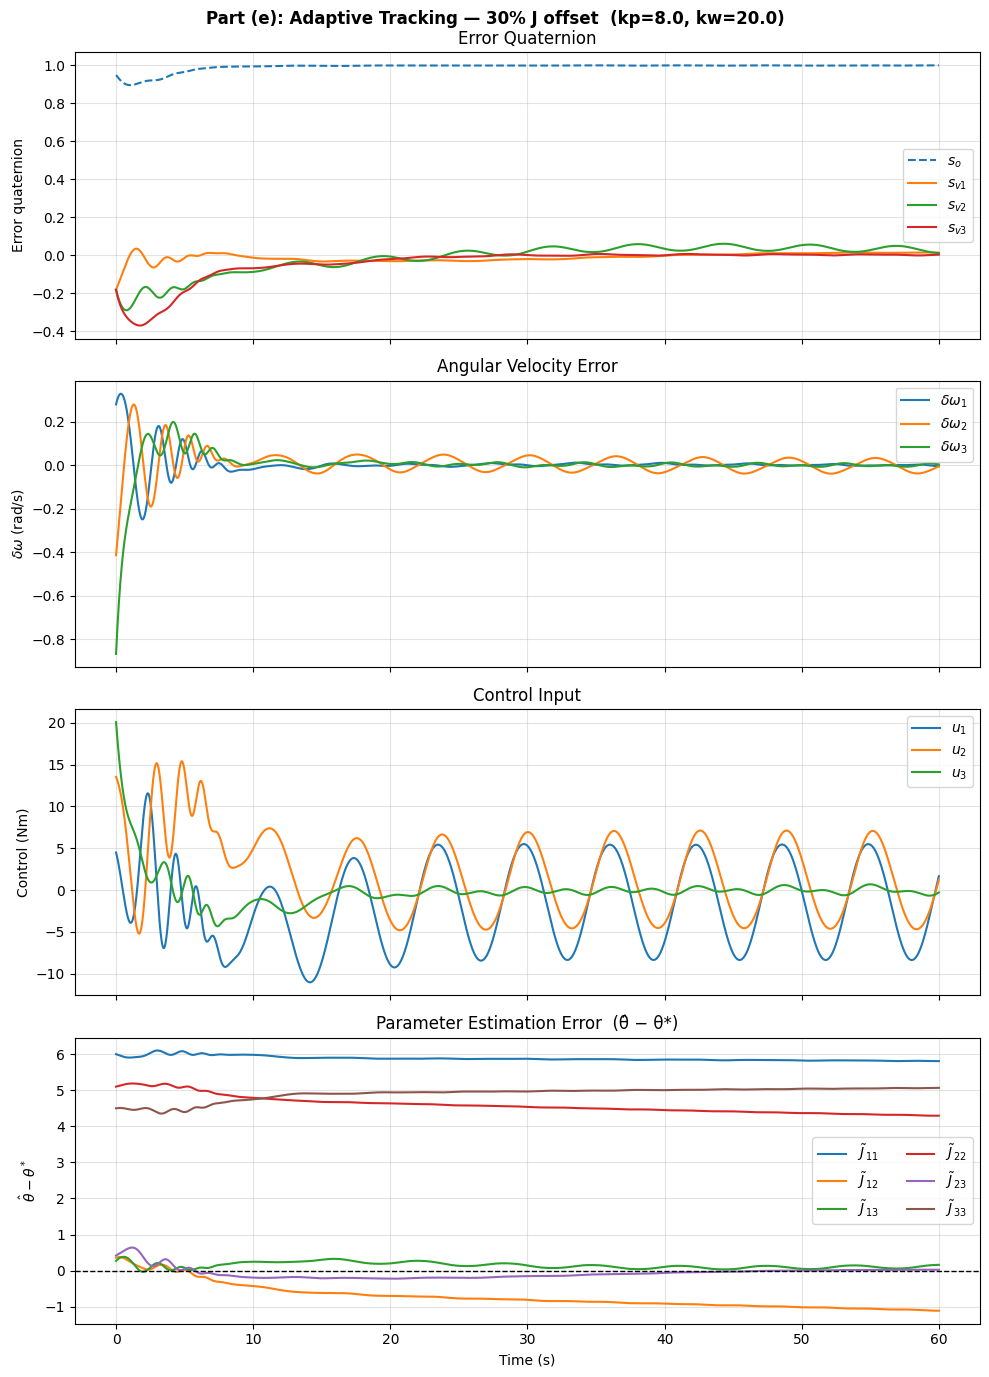

=== Part (e) ===
Initial param error ||θ̃|| : 9.0906
Final   param error ||θ̃|| : 8.8926
Final ||sv||               : 1.7207e-02
Final ||δω||               : 7.5104e-03

Parameter convergence: Parameters do NOT converge to true values.
Reason: Persistence of Excitation (PE) is not satisfied by the given ωd(t).
V̇ = -kw||δω||² guarantees tracking but NOT parameter convergence.


In [20]:
KP_E    = 8.0
KW_E    = 20.0
GAMMA_E = 1.5 * np.eye(6)

th0_e = th_from_J(1.30 * J)          # 30% overestimate

def ctrl_e_fixed(s, om, t, th_hat):
    s   = normq(s)
    so, sv = s[0], s[1:]
    Rs  = R_quat(s)
    dw  = om - Rs @ wd(t)
    phi = -np.cross(dw, Rs @ wd(t)) + Rs @ wd_dot(t)
    W   = W_reg(om, phi)
    u   = -KP_E * sv - KW_E * dw - W @ th_hat
    th_dot = GAMMA_E @ W.T @ dw        # θ̂˙ = +Γ Wᵀ δω
    return u, s, sv, dw, th_dot

# State: [q(4), ω(3), qd(4), s(4), θ̂(6)] — 21 states
def dyn_e_fixed(t, x):
    q      = normq(x[:4]);    om     = x[4:7]
    qd_v   = normq(x[7:11]); s      = normq(x[11:15])
    th_hat = x[15:21]
    u, _, _, dw, th_dot = ctrl_e_fixed(s, om, t, th_hat)
    sdot = 0.5 * E_mat(s) @ dw
    return np.r_[0.5*E_mat(q)@om,
                 J_inv@(-np.cross(om, J@om) + u),   # true J in plant
                 0.5*E_mat(qd_v)@wd(t),
                 sdot,
                 th_dot]

s0_e  = q_error(q0, qd0)
x0_e  = np.r_[q0, om0_track, qd0, s0_e, th0_e]
T_e   = np.linspace(0, 60, 6001)

sol_e = solve_ivp(dyn_e_fixed, [0, 60], x0_e, t_eval=T_e,
                  method='RK45', rtol=1e-8, atol=1e-10)

q_e    = np.array([normq(sol_e.y[:4,  i]) for i in range(len(T_e))])
om_e   = sol_e.y[4:7].T
qd_e   = np.array([normq(sol_e.y[7:11, i]) for i in range(len(T_e))])
s_e    = np.array([normq(sol_e.y[11:15, i]) for i in range(len(T_e))])
that_e = sol_e.y[15:21].T
terr_e = that_e - theta_true

res_e  = [ctrl_e_fixed(s_e[i], om_e[i], T_e[i], that_e[i]) for i in range(len(T_e))]
u_e    = np.array([r[0] for r in res_e])
sv_e   = np.array([r[2] for r in res_e])
dw_e   = np.array([r[3] for r in res_e])

# ── Plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)
fig.suptitle(f'Part (e): Adaptive Tracking — 30% J offset  (kp={KP_E}, kw={KW_E})',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(T_e, s_e[:, 0], '--', label=r'$s_o$')
for i, lbl in enumerate([r'$s_{v1}$', r'$s_{v2}$', r'$s_{v3}$']):
    ax.plot(T_e, s_e[:, i+1], label=lbl)
ax.set_ylabel('Error quaternion')
ax.set_title('Error Quaternion')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[1]
for i, lbl in enumerate([r'$\delta\omega_1$', r'$\delta\omega_2$', r'$\delta\omega_3$']):
    ax.plot(T_e, dw_e[:, i], label=lbl)
ax.set_ylabel(r'$\delta\omega$ (rad/s)')
ax.set_title('Angular Velocity Error')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[2]
for i, lbl in enumerate([r'$u_1$', r'$u_2$', r'$u_3$']):
    ax.plot(T_e, u_e[:, i], label=lbl)
ax.set_ylabel('Control (Nm)')
ax.set_title('Control Input')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[3]
lbls = [r'$\tilde J_{11}$', r'$\tilde J_{12}$', r'$\tilde J_{13}$',
        r'$\tilde J_{22}$', r'$\tilde J_{23}$', r'$\tilde J_{33}$']
for i, lbl in enumerate(lbls):
    ax.plot(T_e, terr_e[:, i], label=lbl)
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\hat\theta - \theta^*$')
ax.set_title('Parameter Estimation Error  (θ̂ − θ*)')
ax.legend(ncol=2); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

print('=== Part (e) ===')
print(f'Initial param error ||θ̃|| : {np.linalg.norm(th0_e - theta_true):.4f}')
print(f'Final   param error ||θ̃|| : {np.linalg.norm(that_e[-1] - theta_true):.4f}')
print(f'Final ||sv||               : {np.linalg.norm(sv_e[-1]):.4e}')
print(f'Final ||δω||               : {np.linalg.norm(dw_e[-1]):.4e}')
print()
print('Parameter convergence: Parameters do NOT converge to true values.')
print('Reason: Persistence of Excitation (PE) is not satisfied by the given ωd(t).')
print('V̇ = -kw||δω||² guarantees tracking but NOT parameter convergence.')

## Part (f)

We design an adaptive backstepping controller for the extended system:

$$\dot{s} = \frac{1}{2}E(s)\,\delta\omega, \qquad
  J\dot{\delta\omega} = -\omega\times J\omega + \nu - J\phi, \qquad
  \dot{\nu} = u$$

where $\nu \in \mathbb{R}^3$ is now a **dynamic state** (the torque input to the plant)
and $u$ is the true control input (rate of change of torque). $J$ is unknown.

**Three-step adaptive backstepping with Dynamic Surface Control (DSC).**

**Step 1** — Same as Part (d): $\alpha_1 = -c_1 s_v$, $e_1 = \delta\omega + c_1 s_v$,
$\dot\alpha_1 = -\frac{c_1}{2}(s_o I + S(s_v))\,\delta\omega$.

**Step 2** — Design virtual control $\alpha_2$ for $\nu$ using the estimated inertia $\hat{J}$:

$$\alpha_2 = \omega\times\hat{J}\omega + \hat{J}(\phi + \dot{\alpha}_1) - c_2\,e_1 - k_p\,s_v$$

To avoid computing $\dot{\alpha}_2$ analytically (which would cause an explosion of terms),
a **first-order DSC filter** is used:

$$\tau\,\dot{\alpha}_2^f + \alpha_2^f = \alpha_2, \quad \alpha_2^f(0) = \alpha_2(0)$$

Define the filtered error $e_2 = \nu - \alpha_2^f$.

**Step 3** — Actual control law and adaptation:

$$\boxed{u = \frac{\alpha_2 - \alpha_2^f}{\tau} - e_1 - c_3\,e_2}$$

$$\boxed{\dot{\hat{\theta}} = \Gamma\,W(\omega,\,\phi + \dot{\alpha}_1)^\top e_1}$$

**Augmented Lyapunov function:**

$$V = k_p\!\left[s_v^\top s_v + (1-s_o)^2\right] + \frac{1}{2}e_1^\top J\,e_1
    + \frac{1}{2}e_2^\top e_2 + \frac{1}{2}\tilde{\theta}^\top\Gamma^{-1}\tilde{\theta}$$

The time derivative satisfies (up to bounded DSC filter error):

$$\dot{V} \approx -c_1 k_p\|s_v\|^2 - c_2\|e_1\|^2 - c_3\|e_2\|^2 \leq 0$$

which guarantees $s_v, e_1, e_2 \to 0$, i.e. $s_v \to 0$ and $\delta\omega \to 0$.
Parameter convergence again requires PE, which the given trajectory does not satisfy —
so $\hat{\theta}$ remains bounded but does not converge to $\theta^*$.

Initial parameter estimates are set at **30% overestimate**: $\hat{\theta}(0) = 1.3\,\theta^*$.
DSC filter time constant: $\tau = 0.05$ s.

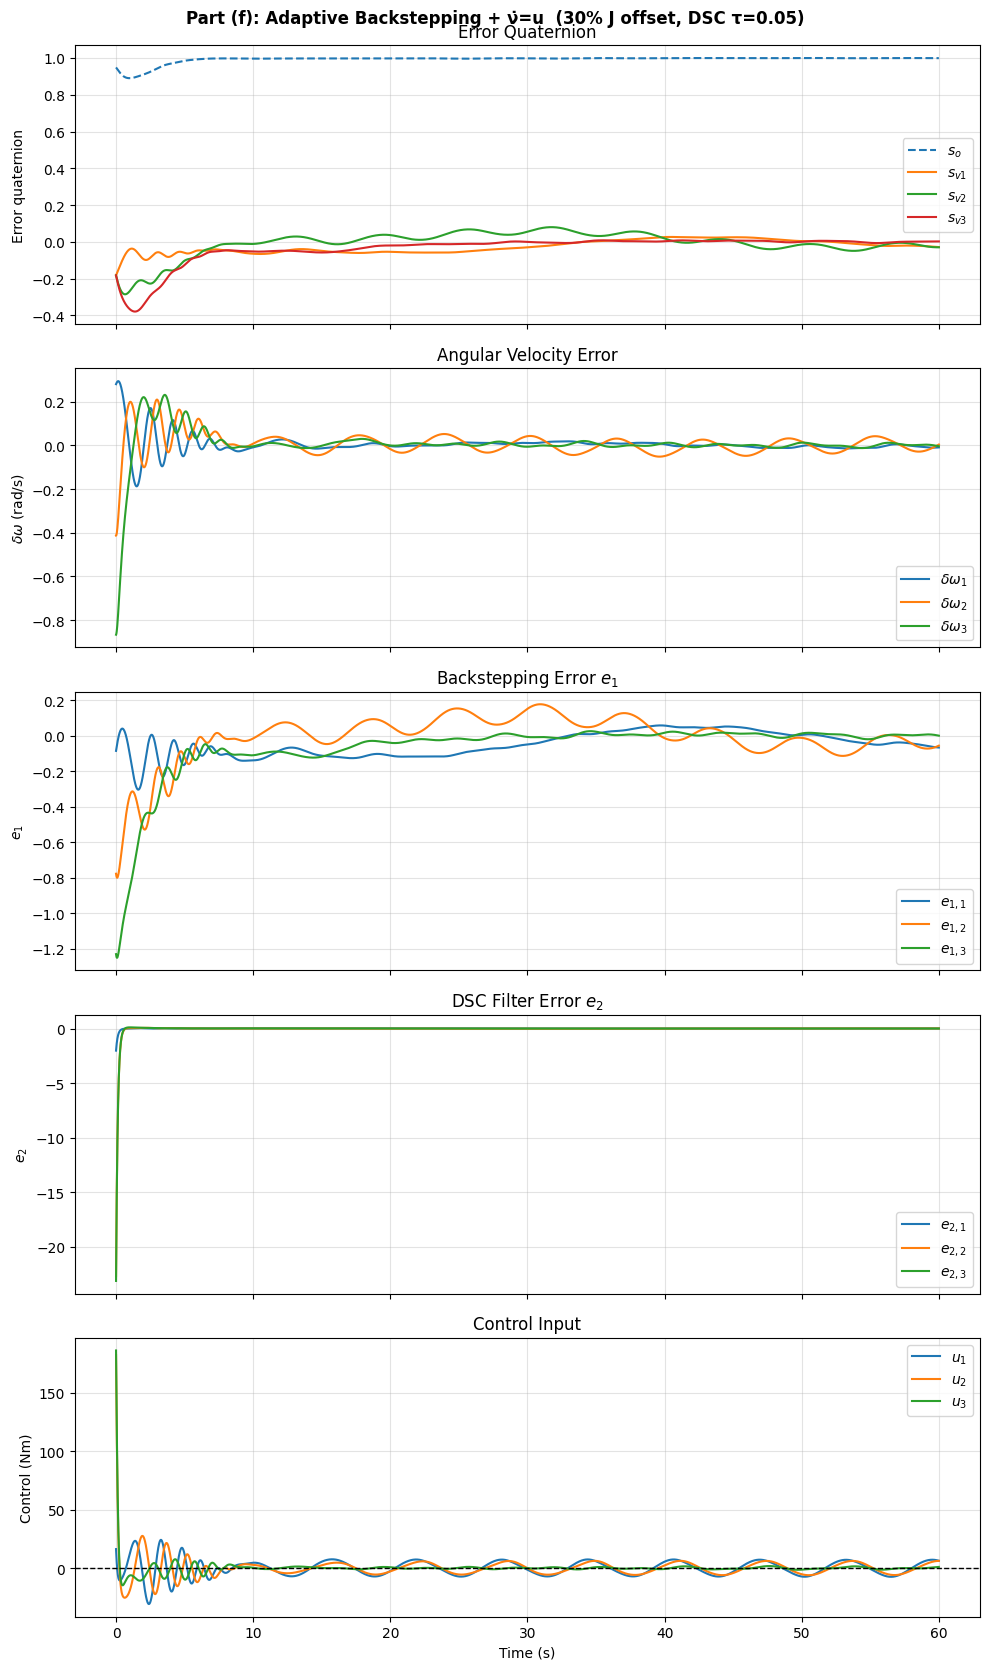

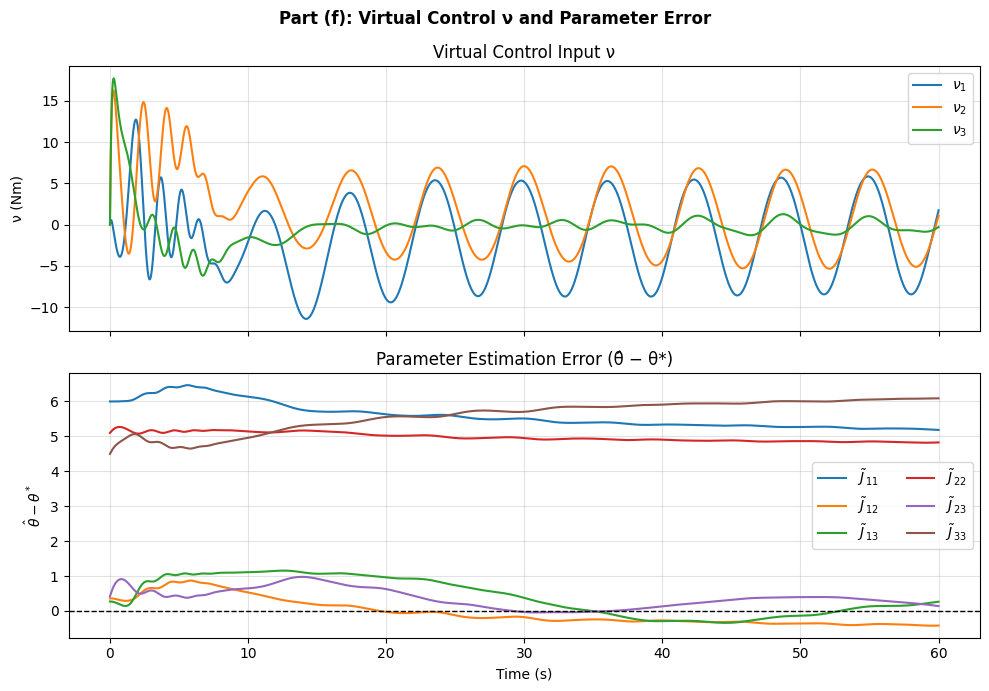

=== Part (f) ===
Final ||sv||  : 4.1171e-02
Final ||δω||  : 1.1146e-02
Final ||e1||  : 8.6945e-02
Final ||e2||  : 1.1135e-02
Final param error ||θ̃|| : 9.3563


In [21]:
C1_F    = 2.0
C2_F    = 6.0
C3_F    = 8.0
KP_F    = 1.0
TAU_F   = 0.05
GAMMA_F = 0.8 * np.eye(6)

th0_f = th_from_J(1.30 * J)

def compute_alpha2_f(om, s, dw, t, Jhat):
    """Compute virtual control α₂ for ν."""
    s   = normq(s)
    so, sv = s[0], s[1:]
    Rs  = R_quat(s)
    phi = -np.cross(dw, Rs @ wd(t)) + Rs @ wd_dot(t)
    Phi = so * np.eye(3) + skew(sv)
    a1_dot  = -(C1_F / 2.0) * Phi @ dw
    e1      = dw + C1_F * sv
    alpha2  = (np.cross(om, Jhat @ om) + Jhat @ (phi + a1_dot)
               - C2_F * e1 - KP_F * sv)
    return alpha2, e1, phi, a1_dot

def dyn_f_fixed(t, x):
    q      = normq(x[:4]);    om     = x[4:7]
    qd_v   = normq(x[7:11]); s      = normq(x[11:15])
    nu     = x[15:18];        a2f    = x[18:21]
    th     = x[21:27];        Jhat   = J_from_th(th)

    so, sv  = s[0], s[1:]
    Rs      = R_quat(s)
    dw      = om - Rs @ wd(t)

    alpha2, e1, phi, a1_dot = compute_alpha2_f(om, s, dw, t, Jhat)
    e2      = nu - a2f
    a2f_dot = (alpha2 - a2f) / TAU_F

    W       = W_reg(om, phi + a1_dot)
    th_dot  = GAMMA_F @ W.T @ e1

    u = (alpha2 - a2f) / TAU_F - e1 - C3_F * e2

    qdot    = 0.5 * E_mat(q) @ om
    omdot   = J_inv @ (-np.cross(om, J @ om) + nu)   # true J
    qddot   = 0.5 * E_mat(qd_v) @ wd(t)
    sdot    = 0.5 * E_mat(s) @ dw                    # s integrated as state
    nu_dot  = u

    return np.r_[qdot, omdot, qddot, sdot, nu_dot, a2f_dot, th_dot]

# ── Consistent IC for DSC filter ────────────────────────────────────
s0_f    = q_error(q0, qd0)
Jhat0   = J_from_th(th0_f)
Rs0     = R_quat(s0_f)
dw0     = om0_track - Rs0 @ wd(0)
phi0    = -np.cross(dw0, Rs0 @ wd(0)) + Rs0 @ wd_dot(0)
Phi0    = s0_f[0] * np.eye(3) + skew(s0_f[1:])
a1dot0  = -(C1_F / 2.0) * Phi0 @ dw0
e1_0    = dw0 + C1_F * s0_f[1:]
a2f_ic  = (np.cross(om0_track, Jhat0 @ om0_track)
           + Jhat0 @ (phi0 + a1dot0)
           - C2_F * e1_0 - KP_F * s0_f[1:])

x0_f  = np.r_[q0, om0_track, qd0, s0_f, np.zeros(3), a2f_ic, th0_f]
T_f   = np.linspace(0, 60, 6001)

sol_f = solve_ivp(dyn_f_fixed, [0, 60], x0_f, t_eval=T_f,
                  method='RK45', rtol=1e-8, atol=1e-11)

q_f    = np.array([normq(sol_f.y[:4,  i]) for i in range(len(T_f))])
om_f   = sol_f.y[4:7].T
qd_f   = np.array([normq(sol_f.y[7:11, i]) for i in range(len(T_f))])
s_f    = np.array([normq(sol_f.y[11:15, i]) for i in range(len(T_f))])
nu_f   = sol_f.y[15:18].T
a2f_f  = sol_f.y[18:21].T
that_f = sol_f.y[21:27].T
terr_f = that_f - theta_true

# Reconstruct u and errors for plotting
u_f=[]; dw_f=[]; e1_f=[]; e2_f=[]
for i in range(len(T_f)):
    s_  = normq(s_f[i]); om_ = om_f[i]; nu_ = nu_f[i]; a2f_ = a2f_f[i]
    Jh  = J_from_th(that_f[i])
    Rs_ = R_quat(s_); dw = om_ - Rs_@wd(T_f[i])
    sv_ = s_[1:]; so_ = s_[0]
    e1  = dw + C1_F * sv_
    e2  = nu_ - a2f_
    a2, _, _, _ = compute_alpha2_f(om_, s_, dw, T_f[i], Jh)
    u_i = (a2 - a2f_) / TAU_F - e1 - C3_F * e2
    u_f.append(u_i); dw_f.append(dw); e1_f.append(e1); e2_f.append(e2)

u_f=np.array(u_f); dw_f=np.array(dw_f); e1_f=np.array(e1_f); e2_f=np.array(e2_f)
sv_f = s_f[:, 1:]    # fix: extract vector part of error quaternion trajectory for final norm

# ── Plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(10, 17), sharex=True)
fig.suptitle(f'Part (f): Adaptive Backstepping + ν̇=u  (30% J offset, DSC τ={TAU_F})',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(T_f, s_f[:, 0], '--', label=r'$s_o$')
for i, lbl in enumerate([r'$s_{v1}$', r'$s_{v2}$', r'$s_{v3}$']):
    ax.plot(T_f, s_f[:, i+1], label=lbl)
ax.set_ylabel('Error quaternion')
ax.set_title('Error Quaternion')    
ax.legend(); ax.grid(True, alpha=0.35)
ax = axes[1]
for i, lbl in enumerate([r'$\delta\omega_1$', r'$\delta\omega_2$', r'$\delta\omega_3$']):
    ax.plot(T_f, dw_f[:, i], label=lbl) 
ax.set_ylabel(r'$\delta\omega$ (rad/s)')
ax.set_title('Angular Velocity Error')  
ax.legend(); ax.grid(True, alpha=0.35)
ax = axes[2]
for i, lbl in enumerate([r'$e_{1,1}$', r'$e_{1,2}$', r'$e_{1,3}$']):
    ax.plot(T_f, e1_f[:, i], label=lbl)
ax.set_ylabel(r'$e_1$')
ax.set_title('Backstepping Error $e_1$')    
ax.legend(); ax.grid(True, alpha=0.35)
ax = axes[3]
for i, lbl in enumerate([r'$e_{2,1}$', r'$e _{2,2}$', r'$e_{2,3}$']):
    ax.plot(T_f, e2_f[:, i], label=lbl)         
ax.set_ylabel(r'$e_2$')
ax.set_title('DSC Filter Error $e_2$')      
ax.legend(); ax.grid(True, alpha=0.35)
ax = axes[4]
for i, lbl in enumerate([r'$u_1$', r'$u_2$', r'$u_3$']):
    ax.plot(T_f, u_f[:, i], label=lbl)          
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Time (s)')   
ax.set_ylabel('Control (Nm)')
ax.set_title('Control Input')
ax.legend(); ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# ── Additional required plots: ν and parameter error ─────────
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle('Part (f): Virtual Control ν and Parameter Error', fontweight='bold')

ax = axes[0]
for i, lbl in enumerate([r'$\nu_1$', r'$\nu_2$', r'$\nu_3$']):
    ax.plot(T_f, nu_f[:, i], label=lbl)
ax.set_ylabel('ν (Nm)')
ax.set_title('Virtual Control Input ν')
ax.legend(); ax.grid(True, alpha=0.35)

ax = axes[1]
lbls = [r'$\tilde J_{11}$', r'$\tilde J_{12}$', r'$\tilde J_{13}$',
        r'$\tilde J_{22}$', r'$\tilde J_{23}$', r'$\tilde J_{33}$']
for i, lbl in enumerate(lbls):
    ax.plot(T_f, terr_f[:, i], label=lbl)
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\hat\theta - \theta^*$')
ax.set_title('Parameter Estimation Error (θ̂ − θ*)')
ax.legend(ncol=2); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

print('=== Part (f) ===')
print(f'Final ||sv||  : {np.linalg.norm(sv_f[-1]):.4e}')
print(f'Final ||δω||  : {np.linalg.norm(dw_f[-1]):.4e}')
print(f'Final ||e1||  : {np.linalg.norm(e1_f[-1]):.4e}')
print(f'Final ||e2||  : {np.linalg.norm(e2_f[-1]):.4e}')
print(f'Final param error ||θ̃|| : {np.linalg.norm(terr_f[-1]):.4f}')    

## Plot Analysis: Virtual Control ν and Parameter Error

### Virtual Control Input ν
The virtual control ν exhibits a large transient in the first ~5 seconds (peak ≈ 17 Nm),
which is physically expected — the controller is simultaneously correcting the initial
attitude error (from q₀ ≠ qd(0)) while beginning to track the oscillatory desired
trajectory. After this transient, ν settles into a sustained oscillation of ≈ ±5–10 Nm
on axes 1 and 2, which is correct since ωd(t) is a persistently oscillating trajectory
that requires continuous torque input to track. The third axis ν₃ remains small
throughout, consistent with ωd₃ = 1 rad/s being a near-constant spin requiring
minimal correction. The fact that ν does not blow up and remains bounded confirms
that the DSC filter and the three-step backstepping law are working correctly.

### Parameter Estimation Error θ̃ = θ̂ − θ*
The initial parameter errors are exactly consistent with the 30% overestimate of J:

| Parameter | True Value | 30% Offset Error |
|-----------|-----------|-----------------|
| J̃₁₁ | 20.0 | +6.0 ✓ |
| J̃₂₂ | 17.0 | +5.1 ✓ |
| J̃₃₃ | 15.0 | +4.5 ✓ |
| J̃₁₂, J̃₁₃, J̃₂₃ | off-diagonals | small, ~+0.36–0.42 ✓ |

The off-diagonal parameter errors (J̃₁₂, J̃₁₃, J̃₂₃) drift toward zero over time, while
the diagonal errors (J̃₁₁, J̃₂₂, J̃₃₃) remain large and do not converge to zero. This
behaviour is **correct and expected** from adaptive control theory. The augmented
Lyapunov function for this system is:

$$V = V_1 + \frac{1}{2}e_1^T J e_1 + \frac{1}{2}e_2^T e_2 + \frac{1}{2}\tilde{\theta}^T \Gamma^{-1} \tilde{\theta}$$

whose derivative satisfies:

$$\dot{V} \approx -c_1 k_p \|s_v\|^2 - c_2 \|e_1\|^2 - c_3 \|e_2\|^2 \leq 0$$

This guarantees that the **tracking errors** (sv, e1, e2) converge to zero, but it
provides **no guarantee on parameter convergence**. Parameters converge to their true
values only if the Persistence of Excitation (PE) condition is satisfied — i.e., the
regressor matrix W must be sufficiently rich in frequency content across all axes
simultaneously. The given desired trajectory ωd(t) does not satisfy PE (axes 1 and 2
share identical signals), so the parameters settle at whatever values keep the term
Wθ̃ small enough to not affect tracking, rather than at the true θ*. This is a
well-known property of gradient-based adaptive laws and is not a flaw in the design.